In [1]:
import torch
import torch.nn.functional as F
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def random_binary_undirected_graph(n_nodes=20, edge_prob=0.2, seed=1):
    G = nx.erdos_renyi_graph(n=n_nodes, p=edge_prob, seed=seed, directed=False)
    return G
def draw_graph(G, seed=42):
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, with_labels=True, node_color="lightblue")
    plt.show()

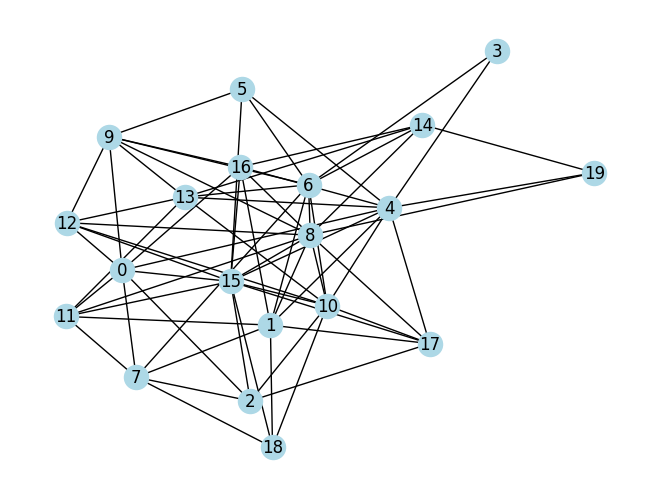

In [3]:
# generate graph
G = random_binary_undirected_graph(n_nodes=20, edge_prob=0.3, seed=7)
draw_graph(G)

In [13]:
def graph_to_binary_adjacency(G):
    n = G.number_of_nodes()
    W = np.zeros((n, n), dtype=np.float32)
    for u, v in G.edges():
        W[u, v] = 1.0
        W[v, u] = 1.0
    return W

def draw_graph_with_mis(G, x, seed=42):
    # x: 0/1 vector, 1 means "selected"
    pos = nx.spring_layout(G, seed=seed)
    node_colors = ["tab:orange" if x[i] == 1 else "tab:blue" for i in G.nodes()]
    nx.draw(G, pos, with_labels=True, node_color=node_colors)
    plt.show()

# adjacency matrix
W = graph_to_binary_adjacency(G)
print("W shape:", W.shape)
print("Unique values in W:", np.unique(W))

W shape: (30, 30)
Unique values in W: [0. 1.]


In [14]:
# --- device ---
device = "mps" if torch.mps.is_available() else "cpu"

# --- graph ---
W = torch.tensor(W, dtype=torch.float32).to(device)

# --- hyperparameters ---
batch = 64
q = 2
n = W.shape[0]
beta_range = torch.linspace(0.5, 20.0, steps=200).to(device)

# --- learnable fields ---
h = torch.nn.Parameter(torch.rand(batch, n, q, device=device))

In [15]:
device

'mps'

In [16]:
def S_bernoulli(p, eps=1e-12):
    # p: (batch, n) prob of x_i=1
    p = p.clamp(eps, 1 - eps)
    return -(p * p.log() + (1 - p) * (1 - p).log()).sum(1)  # (batch,)

def mis_energy(W, p, A=5.0, B=1.0):
    """
    W: (n,n) adjacency (0/1), symmetric, diag=0
    p: (batch,n) with p_i = Prob(x_i=1)
    """
    # expected violations: sum_{i,j} W_ij p_i p_j, divide by 2 to avoid double-count undirected edges
    viol = ((p @ W) * p).sum(1) / 2.0          # (batch,)
    size = p.sum(1)                             # (batch,)
    return A * viol - B * size                  # (batch,)

def argmax_mis(W, p):
    """
    p: (batch,n) probabilities
    returns:
      x: (batch,n) hard 0/1 vector
      size: (batch,) number selected
      violations: (batch,) number of violating edges (counts each undirected edge once)
    """
    x = (p >= 0.5).int()  # or p.argmax for q=2; threshold is fine here
    # count violations: edges where both endpoints are 1
    viol = ((x.float() @ W) * x.float()).sum(1) / 2.0
    size = x.sum(1).float()
    return x, size, viol

In [17]:
def solve_mis(W_np_or_torch, batch=64, lr=0.01, steps=300, A=5.0, B=1.0, beta_min=0.5, beta_max=20.0):
    device = "mps" if torch.mps.is_available() else "cpu"
    W = W_np_or_torch
    if not torch.is_tensor(W):
        W = torch.tensor(W, dtype=torch.float32)
    W = W.to(device)

    n = W.shape[0]

    # We can parameterize a Bernoulli directly with one logit per node:
    h = torch.nn.Parameter(torch.rand(batch, n, device=device))
    opt = torch.optim.Adam([h], lr=lr)
    beta_range = torch.linspace(beta_min, beta_max, steps=steps).to(device)

    for beta in beta_range:
        p = torch.sigmoid(h)  # (batch,n), prob node selected
        Fval = mis_energy(W, p, A=A, B=B) - S_bernoulli(p) / beta

        opt.zero_grad()
        Fval.backward(torch.ones_like(Fval))
        opt.step()

    # readout
    p = torch.sigmoid(h)
    x, size, viol = argmax_mis(W, p)

    # choose best: prioritize zero violations, then max size
    # score = very large penalty for violations, so valid sets win
    score = size - 1e6 * viol
    best = score.argmax().item()

    return {
        "best_x": x[best].detach().cpu().numpy(),
        "best_size": float(size[best].item()),
        "best_violations": float(viol[best].item()),
        "all_sizes": size.detach().cpu().numpy(),
        "all_violations": viol.detach().cpu().numpy(),
    }

Best MIS size: 0.0
Violations (should be 0): 0.0
Best x (1=selected): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


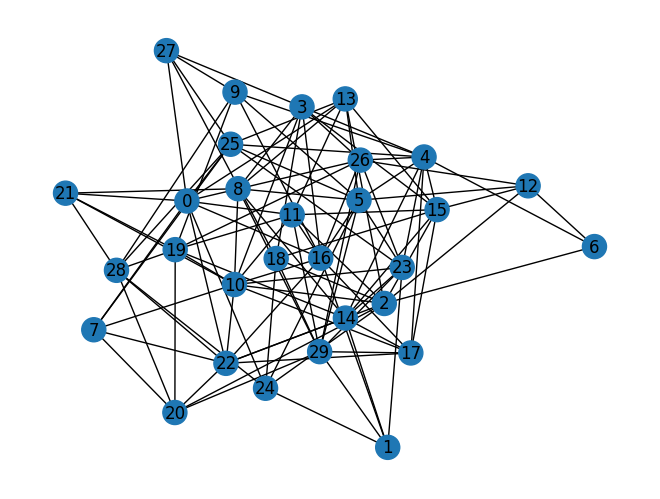

In [18]:
if __name__ == "__main__":
    # Params can be changed
    n_nodes   = 30
    edge_prob = 0.25
    seed      = 11

    batch     = 64
    steps     = 200
    lr        = 0.05
    beta_min  = 0.5
    beta_max  = 20.0
    A         = 30.0
    B         = 1.0

    # Build graph
    G = random_binary_undirected_graph(n_nodes=n_nodes, edge_prob=edge_prob, seed=seed)
    W = graph_to_binary_adjacency(G)

    # Solve MIS
    out = solve_mis(W, batch=batch, lr=lr, steps=steps, beta_min=beta_min, beta_max=beta_max, A=A, B=B)

    print("Best MIS size:", out["best_size"])
    print("Violations (should be 0):", out["best_violations"])
    print("Best x (1=selected):", out["best_x"])

    # Visualize
    draw_graph_with_mis(G, out["best_x"])